# Parte B – Stima dei Beta, Frontiera Efficiente, CAPM

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

TICKERS = {
    'Tech':       ['AAPL', 'MSFT', 'NVDA'],
    'Healthcare': ['JNJ',  'PFE',  'MRK'],
    'Energy':     ['XOM',  'CVX',  'BP'],
    'Index':      ['^GSPC'],
}
ALL_TICKERS = [t for group in TICKERS.values() for t in group]

# 5 titoli scelti nella Parte A per il confronto delle frontiere
SELECTED = ['NVDA', 'MSFT', 'JNJ', 'MRK', 'XOM']

# Parametri economici: identici alla Parte A
rf_annual = 0.02        # tasso risk-free annuo (proxy BOT 3 mesi 2015-2025)
ann       = 12          # fattore di annualizzazione
rf        = rf_annual / ann    # tasso mensile: 0.1667%

START = '2015-01-01'
END   = '2025-01-01'

# Palette colori settori (identica alla Parte A)
palette = {'Tech': 'steelblue', 'Healthcare': 'seagreen',
           'Energy': 'tomato', 'Index': 'black'}
sector_map = {}
for sector, tickers in TICKERS.items():
    for t in tickers:
        sector_map['SP500' if t == '^GSPC' else t] = sector

print('Titoli:', ALL_TICKERS)
print(f'rf = {rf_annual*100:.1f}% annuo | Periodo: {START} → {END}')

Titoli: ['AAPL', 'MSFT', 'NVDA', 'JNJ', 'PFE', 'MRK', 'XOM', 'CVX', 'BP', '^GSPC']
rf = 2.0% annuo | Periodo: 2015-01-01 → 2025-01-01


---
## Blocco 1 – Download dati e rendimenti

In [10]:
raw    = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True, progress=True)
prices = raw['Close'].resample('ME').last()
prices.columns = [c if c != '^GSPC' else 'SP500' for c in prices.columns]
prices.dropna(how='all', inplace=True)

# Rendimenti logaritmici mensili: r_t = ln(P_t / P_{t-1})
returns = np.log(prices / prices.shift(1)).dropna()

# Serie del mercato (proxy: SP500) usata come regressore in tutte le OLS
r_m      = returns['SP500']
mu_m     = r_m.mean()              # rendimento medio mensile del mercato
sigma2_m = np.var(r_m, ddof=1)     # varianza mensile del mercato (ddof=1)
RISKY    = list(returns.columns)   # tutti i 10 titoli (incluso SP500)

print(f'Osservazioni: {len(returns)} mesi  ({returns.index[0].date()} → {returns.index[-1].date()})')
print(f'μ mercato mensile: {mu_m*100:.3f}%  |  σ² mercato mensile: {sigma2_m*10000:.4f}×10⁻⁴')
returns.head(3)

[*********************100%***********************]  10 of 10 completed

Osservazioni: 119 mesi  (2015-02-28 → 2024-12-31)
μ mercato mensile: 0.909%  |  σ² mercato mensile: 19.6899×10⁻⁴


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
Date,,,,,,,,,,
2015-02-28,0.096016,0.079706,0.049455,0.030367,-0.029290,0.089036,0.142699,0.102492,0.020229,0.053439
2015-03-31,-0.031874,-0.057869,-0.016064,-0.018808,-0.010214,-0.075530,-0.052583,0.013602,-0.040803,-0.017549
2015-04-30,0.005770,0.098536,0.056301,-0.014014,0.035547,0.179201,0.058908,-0.025031,0.027500,0.008485


---
## Blocco 2 – Stima OLS dei beta e degli alpha (Punto 8)

In [11]:
# =============================================================================
# FUNZIONE OLS


# =============================================================================
def ols_stats(y_series, x_series):
    """
    OLS: y_t = alpha + beta * x_t + eps_t
    Restituisce stime, errori standard, t-stat, p-value e R².
    """
    y, x = np.array(y_series, float), np.array(x_series, float)
    T    = len(y)

    beta  = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
    alpha = y.mean() - beta * x.mean()

    # Residui e varianza residua (ddof = T-2: due parametri stimati)
    eps = y - alpha - beta * x
    s2  = (eps @ eps) / (T - 2)

    # Errori standard
    Sxx  = ((x - x.mean())**2).sum()     # = (T-1) * Var(x, ddof=1)
    se_b = np.sqrt(s2 / Sxx)
    se_a = np.sqrt(s2 * (1/T + x.mean()**2 / Sxx))

    # t-stat e p-value (due code, distribuzione t con T-2 dof)
    t_b, t_a = beta / se_b, alpha / se_a
    p_b = 2 * stats.t.sf(abs(t_b), df=T - 2)
    p_a = 2 * stats.t.sf(abs(t_a), df=T - 2)

    R2 = 1 - (eps @ eps) / ((y - y.mean())**2).sum()

    return dict(alpha=alpha, beta=beta, se_a=se_a, se_b=se_b,
                t_a=t_a, t_b=t_b, p_a=p_a, p_b=p_b,
                R2=R2, eps=eps, s2=s2)

# Simboli di significatività standard
def sig_stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

# =============================================================================
# STIMA OLS PER TUTTI I 10 TITOLI
# =============================================================================
ols = {t: ols_stats(returns[t], r_m) for t in RISKY}

# Tabella riassuntiva
rows = []
for t in RISKY:
    o = ols[t]
    rows.append({
        'Ticker':        t,
        'Alpha ann (%)': round(o['alpha'] * ann * 100, 3),
        't(α)':          round(o['t_a'], 3),
        'Sig α':         sig_stars(o['p_a']),
        'Beta':          round(o['beta'], 4),
        't(β)':          round(o['t_b'], 3),
        'Sig β':         sig_stars(o['p_b']),
        'R²':            round(o['R2'], 4),
    })

tab_ols = pd.DataFrame(rows).set_index('Ticker')
print(f'OLS: r_i = alpha + beta * r_m + eps   (T = {len(returns)} mesi)\n')
display(tab_ols)
print('\nLegenda: *** p<0.01  ** p<0.05  * p<0.10')

OLS: r_i = alpha + beta * r_m + eps   (T = 119 mesi)



,Alpha ann (%),t(α),Sig α,Beta,t(β),Sig β,R²
Ticker,,,,,,,
AAPL,9.566,1.473,,1.2143,1.012100e+01,***,0.4668
BP,-4.485,-0.598,,0.7039,5.080000e+00,***,0.1807
CVX,-3.873,-0.563,,1.0696,8.418000e+00,***,0.3772
JNJ,0.377,0.088,,0.5607,7.106000e+00,***,0.3015
MRK,3.946,0.663,,0.4268,3.882000e+00,***,0.1141
MSFT,14.737,3.051,***,0.9582,1.074000e+01,***,0.4964
NVDA,37.872,3.194,***,1.7750,8.105000e+00,***,0.3596
PFE,-4.036,-0.606,,0.6320,5.139000e+00,***,0.1842
XOM,-3.956,-0.537,,0.9577,7.037000e+00,***,0.2974



Legenda: *** p<0.01  ** p<0.05  * p<0.10


---
## Blocco 3 – Visualizzazione dei beta e degli alpha (Punto 8)

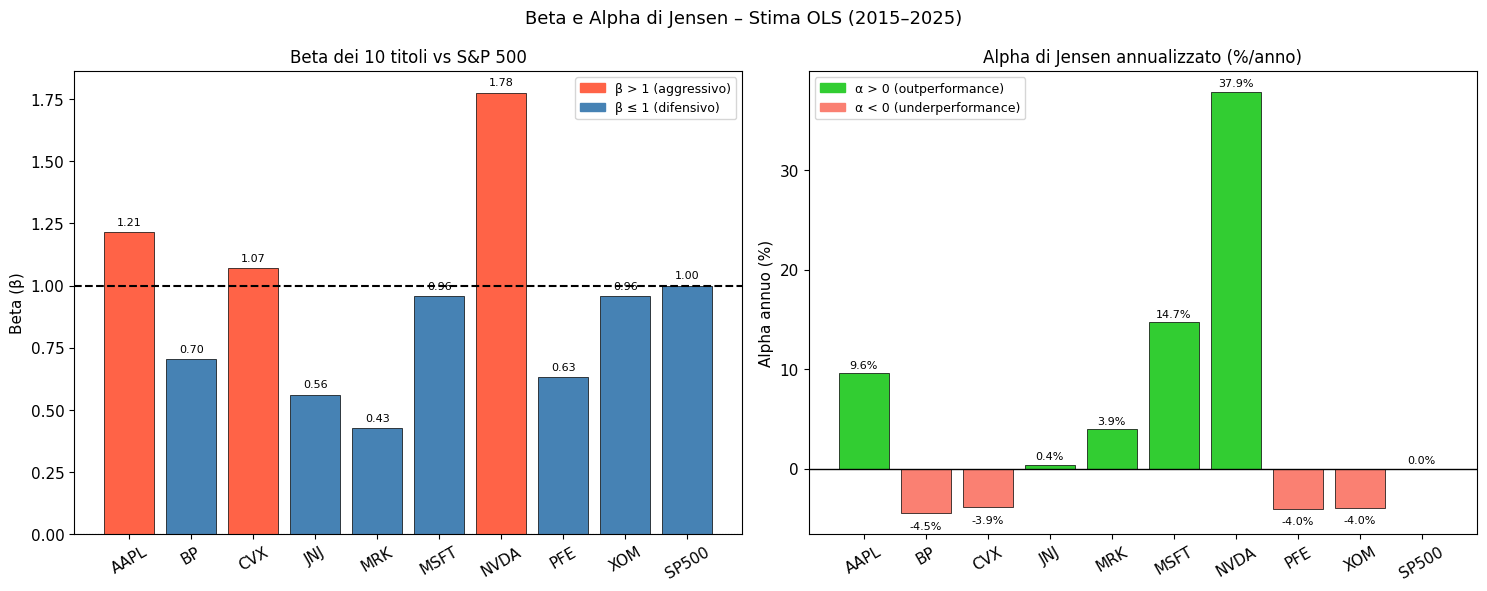

Salvato: beta_alpha_B8.png


In [12]:
betas_all  = [ols[t]['beta']          for t in RISKY]
alphas_ann = [ols[t]['alpha']*ann*100 for t in RISKY]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
colors_b = ['tomato' if b > 1 else 'steelblue' for b in betas_all]
bars = ax.bar(RISKY, betas_all, color=colors_b, edgecolor='black', lw=0.5)
ax.axhline(1.0, color='black', lw=1.5, ls='--', label='β = 1 (mercato)')
ax.axhline(0.0, color='grey',  lw=0.8, ls=':')
for bar, b in zip(bars, betas_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{b:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_title('Beta dei 10 titoli vs S&P 500', fontsize=12)
ax.set_ylabel('Beta (β)')
ax.tick_params(axis='x', rotation=30)
ax.legend(handles=[mpatches.Patch(color='tomato',    label='β > 1 (aggressivo)'),
                   mpatches.Patch(color='steelblue', label='β ≤ 1 (difensivo)')], fontsize=9)

ax = axes[1]
colors_a = ['limegreen' if a > 0 else 'salmon' for a in alphas_ann]
bars_a   = ax.bar(RISKY, alphas_ann, color=colors_a, edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=1)
for bar, a in zip(bars_a, alphas_ann):
    ypos = bar.get_height() + 0.3 if a >= 0 else bar.get_height() - 1.8
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{a:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_title('Alpha di Jensen annualizzato (%/anno)', fontsize=12)
ax.set_ylabel('Alpha annuo (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(handles=[mpatches.Patch(color='limegreen', label='α > 0 (outperformance)'),
                   mpatches.Patch(color='salmon',    label='α < 0 (underperformance)')], fontsize=9)

fig.suptitle('Beta e Alpha di Jensen – Stima OLS (2015–2025)', fontsize=13)
fig.tight_layout()
fig.savefig('beta_alpha_B8.png', dpi=150)
plt.show()
print('Salvato: beta_alpha_B8.png')

---
## Blocco 4 – Security Market Line (Punto 8)

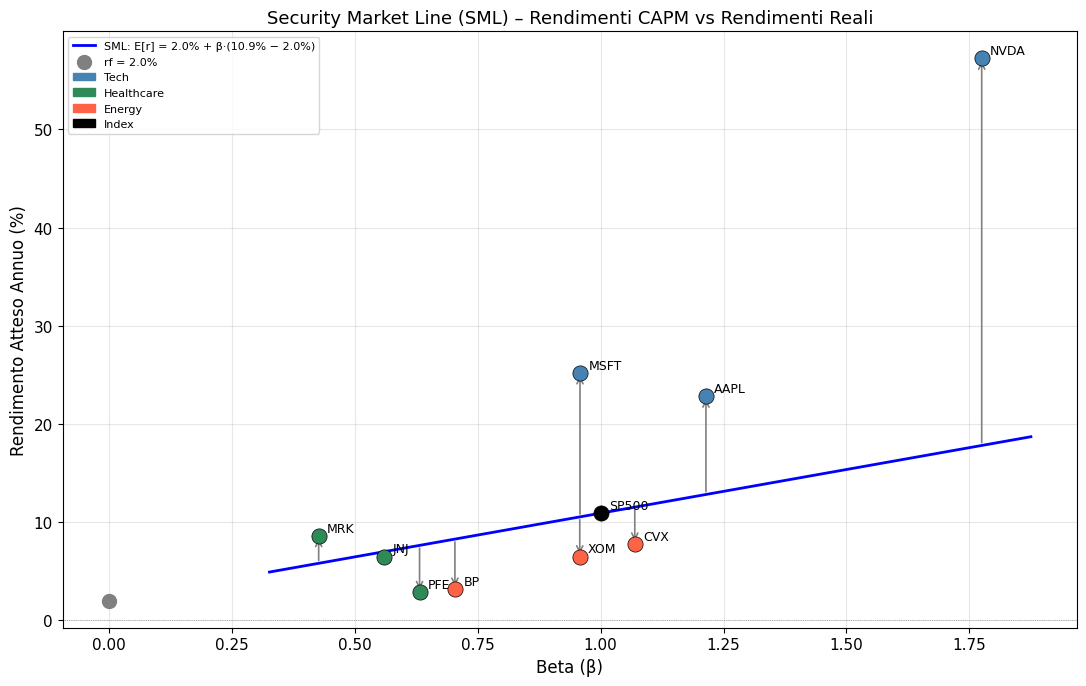

Salvato: SML_B8.png


In [13]:
betas_arr   = np.array([ols[t]['beta']    for t in RISKY])
mu_emp_all  = np.array([returns[t].mean() for t in RISKY])
mu_capm_all = rf + betas_arr * (mu_m - rf)   # CAPM previsto mensile

# Retta SML: E[r] = rf + beta * (mu_m - rf)
beta_grid = np.linspace(min(betas_arr) - 0.1, max(betas_arr) + 0.1, 200)
mu_sml    = rf + beta_grid * (mu_m - rf)

fig, ax = plt.subplots(figsize=(11, 7))

# SML
ax.plot(beta_grid, mu_sml * ann * 100, 'b-', lw=2,
        label=f'SML: E[r] = {rf_annual*100:.1f}% + β·({mu_m*ann*100:.1f}% − {rf_annual*100:.1f}%)')

# Punto risk-free (beta=0)
ax.scatter(0, rf_annual * 100, color='grey', s=100, marker='o', zorder=5,
           label=f'rf = {rf_annual*100:.1f}%')

for i, t in enumerate(RISKY):
    color = palette[sector_map[t]]
    mu_real = mu_emp_all[i] * ann * 100
    mu_pred = mu_capm_all[i] * ann * 100
    ax.scatter(betas_arr[i], mu_real, color=color, s=120, zorder=5,
               edgecolors='black', lw=0.5)
    ax.annotate(t, (betas_arr[i], mu_real),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
    # Freccia verticale che visualizza l'alpha (distanza dalla SML)
    if abs(mu_real - mu_pred) > 1.5:
        ax.annotate('', xy=(betas_arr[i], mu_real),
                    xytext=(betas_arr[i], mu_pred),
                    arrowprops=dict(arrowstyle='->', color='grey', lw=1.2))

# Legenda settori
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in palette.items()]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_patches, fontsize=8, loc='upper left')

ax.set_xlabel('Beta (β)', fontsize=12)
ax.set_ylabel('Rendimento Atteso Annuo (%)', fontsize=12)
ax.set_title('Security Market Line (SML) – Rendimenti CAPM vs Rendimenti Reali', fontsize=13)
ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('SML_B8.png', dpi=150)
plt.show()
print('Salvato: SML_B8.png')

---
## Blocco 5 – Matrice varianza-covarianza via Single Index Model (Punto 9)

In [ ]:
s2eps_arr = np.array([ols[t]['s2'] for t in RISKY])   # sigma2_eps_i per ogni titolo
Sigma_SIM = np.outer(betas_arr, betas_arr) * sigma2_m + np.diag(s2eps_arr)

var_emp = np.array([returns[t].var(ddof=1) for t in RISKY])
var_sim = np.diag(Sigma_SIM)

print('Verifica: Var(SIM) == Var(empirica) – devono coincidere per costruzione:\n')
check = pd.DataFrame({
    'Var SIM (×10⁴)':      (var_sim * 10000).round(4),
    'Var empirica (×10⁴)': (var_emp * 10000).round(4),
    'Differenza (×10⁶)':   ((var_sim - var_emp) * 1e6).round(4),
}, index=RISKY)
display(check)

# Confronto matrici di correlazione: SIM vs empirica
D_inv    = np.diag(1 / np.sqrt(var_sim))
Corr_SIM = pd.DataFrame(D_inv @ Sigma_SIM @ D_inv, index=RISKY, columns=RISKY)
Corr_emp = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, corr, title in zip(axes,
                            [Corr_SIM, Corr_emp],
                            ['Correlazione SIM  (solo fattore mercato)',
                             'Correlazione Empirica  (storica)']):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, square=True,
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(title, fontsize=12)
fig.suptitle('Confronto correlazioni: SIM vs Empirica\n'
             'Il SIM appiattisce le correlazioni perché ignora co-movimenti idiosincratici', fontsize=12)
fig.tight_layout()
fig.savefig('correlation_SIM_vs_empirical_B9.png', dpi=150)
plt.show()
print('Salvato: correlation_SIM_vs_empirical_B9.png')

Verifica: Var(SIM) == Var(empirica) – devono coincidere per costruzione:



,Var SIM (×10⁴),Var empirica (×10⁴),Differenza (×10⁶)
AAPL,62.4779,62.1945,28.3428
BP,54.3601,53.9821,37.8011
CVX,60.0347,59.7168,31.7867
JNJ,20.6531,20.5305,12.2571
MRK,31.6683,31.4303,23.7978
MSFT,36.5692,36.4125,15.6717
NVDA,173.4849,172.5404,94.4472
PFE,42.9957,42.6979,29.7728
XOM,61.0939,60.7292,36.4696
SP500,19.6899,19.6899,-0.0000


---
## Blocco 6 – Rendimenti attesi, deviazioni standard e confronto CAPM (Punto 9)

Punto 9 – Confronto μ e σ: empirico vs CAPM/SIM (annualizzati)



,Beta,μ CAPM annuo (%),μ Empirico annuo (%),σ SIM annua (%),σ Empirica annua (%),Alpha annuo (%),p-value α,Significatività
AAPL,1.2143,12.81,22.81,27.38,27.32,9.99,0.1435,
BP,0.7039,8.27,3.19,25.54,25.45,-5.08,0.5511,
CVX,1.0696,11.52,7.79,26.84,26.77,-3.73,0.5744,
JNJ,0.5607,6.99,6.49,15.74,15.70,-0.50,0.9299,
MRK,0.4268,5.80,8.60,19.49,19.42,2.80,0.5086,
MSFT,0.9582,10.53,25.18,20.95,20.90,14.65,0.0028,***
NVDA,1.7750,17.80,57.22,45.63,45.50,39.42,0.0018,***
PFE,0.6320,7.63,2.85,22.71,22.64,-4.77,0.5455,
XOM,0.9577,10.53,6.49,27.08,27.00,-4.04,0.5923,
SP500,1.0000,10.90,10.90,15.37,15.37,0.00,0.0658,*



Nota: σ SIM ≈ σ empirica per i singoli asset (diagonale Sigma_SIM preservata)
      Le differenze nelle frontiere vengono dai termini off-diagonali (covarianze)


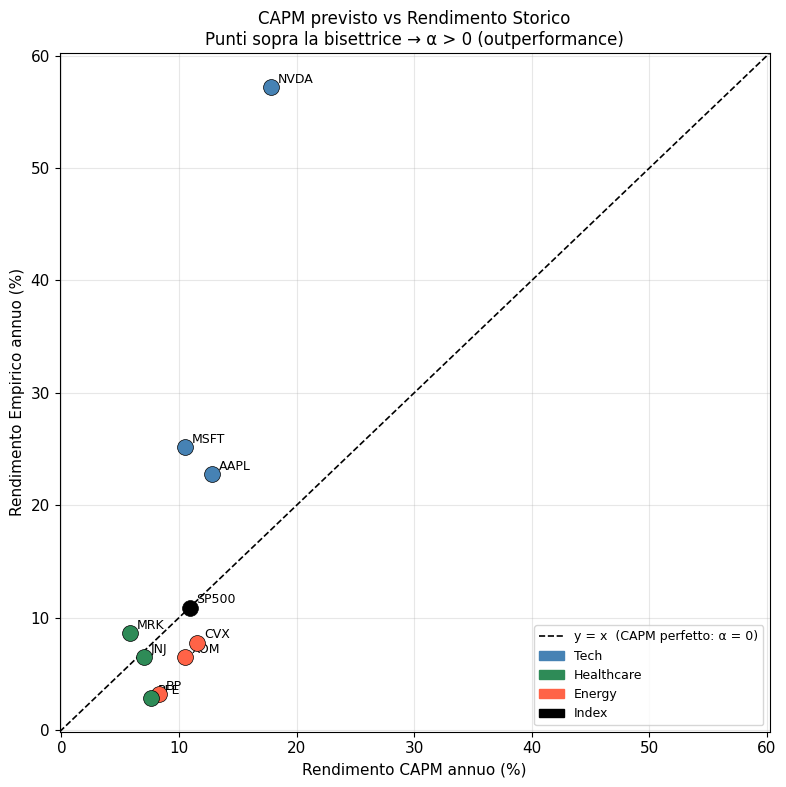

Salvato: capm_vs_empirical_B9.png


In [ ]:
mu_capm_arr = rf + betas_arr * (mu_m - rf)     # array (N,) mensile
mu_emp_arr  = np.array([returns[t].mean() for t in RISKY])

sigma_sim_ann = np.sqrt(np.diag(Sigma_SIM)) * np.sqrt(ann) * 100   # annualizzata
sigma_emp_ann = np.array([returns[t].std()  for t in RISKY]) * np.sqrt(ann) * 100

# Tabella riepilogativa completa: mu CAPM, sigma SIM, alpha (Punto 9)
comp = pd.DataFrame({
    'Beta':                   betas_arr.round(4),
    'μ CAPM annuo (%)':       (mu_capm_arr * ann * 100).round(2),
    'μ Empirico annuo (%)':   (mu_emp_arr  * ann * 100).round(2),
    'σ SIM annua (%)':        sigma_sim_ann.round(2),
    'σ Empirica annua (%)':   sigma_emp_ann.round(2),
    'Alpha annuo (%)':        ((mu_emp_arr - mu_capm_arr) * ann * 100).round(2),
    'p-value α':              [round(ols[t]['p_a'], 4) for t in RISKY],
    'Significatività':        [sig_stars(ols[t]['p_a']) for t in RISKY],
}, index=RISKY)

print('Punto 9 – Confronto μ e σ: empirico vs CAPM/SIM (annualizzati)\n')
display(comp)
print('\nNota: σ SIM ≈ σ empirica per i singoli asset (diagonale Sigma_SIM preservata)')
print('      Le differenze nelle frontiere vengono dai termini off-diagonali (covarianze)')

# Scatter: mu_empirico vs mu_CAPM (se CAPM fosse perfetto → tutti sulla bisettrice)
fig, ax = plt.subplots(figsize=(8, 8))
all_mu = np.concatenate([mu_capm_arr, mu_emp_arr]) * ann * 100
lim    = (min(all_mu) - 3, max(all_mu) + 3)
ax.plot(lim, lim, 'k--', lw=1.2, label='y = x  (CAPM perfetto: α = 0)')

for i, t in enumerate(RISKY):
    color = palette[sector_map[t]]
    ax.scatter(mu_capm_arr[i]*ann*100, mu_emp_arr[i]*ann*100,
               color=color, s=130, zorder=4, edgecolors='black', lw=0.5)
    ax.annotate(t, (mu_capm_arr[i]*ann*100, mu_emp_arr[i]*ann*100),
                textcoords='offset points', xytext=(5, 3), fontsize=9)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Rendimento CAPM annuo (%)'); ax.set_ylabel('Rendimento Empirico annuo (%)')
ax.set_title('CAPM previsto vs Rendimento Storico\n'
             'Punti sopra la bisettrice → α > 0 (outperformance)', fontsize=12)
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in palette.items()]
ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_patches, fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('capm_vs_empirical_B9.png', dpi=150)
plt.show()
print('Salvato: capm_vs_empirical_B9.png')

---
## Blocco 7 – Frontiera efficiente SIM/CAPM vs Empirica (Punto 9)

In [ ]:
# Estrai parametri per i 5 titoli selezionati 
sel_idx  = [RISKY.index(t) for t in SELECTED]   

mu5_emp  = np.array([returns[t].mean() for t in SELECTED])  
Sig5_emp = returns[SELECTED].cov().values                     

mu5_capm = mu_capm_arr[sel_idx]                               
Sig5_SIM = Sigma_SIM[np.ix_(sel_idx, sel_idx)]              

# Funzione frontiera analitica (scalari di Markowitz)
def markowitz_frontier(mu_vec, Sig_mat, n_pts=300):
    """
    Frontiera efficiente analitica data μ e Σ.
    Usa le formule dei scalari A, B, C, D della Parte A.
    Ritorna (sigma_annua %, mu_annua %, mu_gmv mensile).
    """
    iota = np.ones(len(mu_vec))
    Sinv = np.linalg.inv(Sig_mat)
    A_mk = float(iota @ Sinv @ mu_vec)       # A = 1'Σ⁻¹μ
    B_mk = float(mu_vec @ Sinv @ mu_vec)     # B = μ'Σ⁻¹μ
    C_mk = float(iota @ Sinv @ iota)         # C = 1'Σ⁻¹1
    D_mk = B_mk * C_mk - A_mk**2            # D = BC - A²
    mu_gmv  = A_mk / C_mk                   # μ_GMV = A/C
    mu_grid = np.linspace(mu_gmv, mu_vec.max() * 1.6, n_pts)
    sig_grid = np.sqrt((C_mk * mu_grid**2 - 2*A_mk*mu_grid + B_mk) / D_mk)
    return sig_grid * np.sqrt(ann) * 100, mu_grid * ann * 100, mu_gmv

# Frontiere
sig_emp_f, mu_emp_f, mu_gmv_emp = markowitz_frontier(mu5_emp,  Sig5_emp)
sig_sim_f, mu_sim_f, mu_gmv_sim = markowitz_frontier(mu5_capm, Sig5_SIM)

# Grafico confronto
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(sig_emp_f, mu_emp_f, 'b-',  lw=2.5,
        label='Frontiera empirica  (μ empirico, Σ empirica) – Parte A')
ax.plot(sig_sim_f, mu_sim_f, 'r--', lw=2.5,
        label='Frontiera SIM/CAPM  (μ_CAPM, Σ_SIM) – Parte B')

for i, t in enumerate(SELECTED):
    sig_a = returns[t].std()  * np.sqrt(ann) * 100
    mu_a  = returns[t].mean() * ann * 100
    mu_c  = mu5_capm[i] * ann * 100
    ax.scatter(sig_a, mu_a, s=110, marker='o', color='steelblue',
               zorder=5, edgecolors='black', lw=0.5)
    ax.scatter(sig_a, mu_c, s=110, marker='x', color='red',
               zorder=5, linewidths=2)
    ax.annotate(t, (sig_a, mu_a), textcoords='offset points', xytext=(5, 3), fontsize=9)

extra_legend = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=9, markeredgecolor='black', label='Asset: μ empirico'),
    Line2D([0],[0], marker='x', color='red', markersize=9,
           lw=0, markeredgewidth=2, label='Asset: μ CAPM'),
]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + extra_legend, fontsize=9)

ax.set_xlabel('Deviazione Standard Annua (%)', fontsize=12)
ax.set_ylabel('Rendimento Atteso Annuo (%)', fontsize=12)
ax.set_title('Frontiera Efficiente: Empirica (Parte A) vs SIM/CAPM (Parte B)\n'
             '5 titoli selezionati – short selling ammesso', fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('frontier_SIM_vs_empirical_B9.png', dpi=150)
plt.show()
print('Salvato: frontier_SIM_vs_empirical_B9.png')

print('\nCommento:')
print('- La frontiera SIM/CAPM differisce da quella empirica principalmente')
print('  per i rendimenti attesi: μ_CAPM=rf+β(μ_m-rf) può differire molto')
print('  dai rendimenti storici quando gli alpha di Jensen sono grandi.')
print('- La struttura delle covarianze SIM è più parsimoniosa (2N+1 param.)')
print('  ma può perdere informazione sulle correlazioni idiosincratiche.')